In [40]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

def set_global_seed(seed_value=42):
    # 1. Thiết lập seed cho môi trường Python (Environment Variable)
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    
    # 2. Thiết lập seed cho các hàm random cơ bản của Python
    random.seed(seed_value)
    
    # 3. Thiết lập seed cho NumPy (ảnh hưởng đến việc xáo trộn/chia dữ liệu)
    np.random.seed(seed_value)
    
    # 4. Thiết lập seed cho TensorFlow (ảnh hưởng đến khởi tạo trọng số, Dropout)
    tf.random.set_seed(seed_value)
    
    # (Tùy chọn cho GPU) Ép TensorFlow chạy các thuật toán có tính tất định
    tf.config.experimental.enable_op_determinism()

# Gọi hàm ngay trước khi tải dữ liệu hoặc định nghĩa mô hình
set_global_seed(42)

In [41]:
# -------- Binary activation --------
def binary_activation(x):
    x_bin = tf.sign(x)
    return x + tf.stop_gradient(x_bin - x)


In [42]:

# -------- Binary Dense Layer --------
class BinaryDense(layers.Layer):

    def __init__(self, units, activation=None):
        super(BinaryDense, self).__init__()
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.w = self.add_weight(
            shape=(input_shape[-1], self.units),
            initializer="glorot_uniform",
            trainable=True
        )
        self.b = self.add_weight(
            shape=(self.units,),
            initializer="zeros",
            trainable=True
        )

    def call(self, inputs):

        # Binarize weight
        w_bin = tf.sign(self.w)

        # Straight Through Estimator
        w_bin = self.w + tf.stop_gradient(w_bin - self.w)

        output = tf.matmul(inputs, w_bin) + self.b

        if self.activation is not None:
            output = self.activation(output)

        return output



In [43]:

# -------- Load MNIST --------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = (x_train / 127.5) - 1.0
x_test = (x_test / 127.5) - 1.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)


In [44]:
# -------- BNN Model --------
bnn_model = models.Sequential([

    BinaryDense(256),
    layers.BatchNormalization(),
    layers.Activation(binary_activation),

    BinaryDense(128),
    layers.BatchNormalization(),
    layers.Activation(binary_activation),

    layers.Dense(10), 
    layers.Activation("softmax")
])



In [45]:
my_learning_rate = 0.001
my_epochs = 7
my_batch_size = 32



# -------- Compile --------
bnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=my_learning_rate),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# -------- Training --------
print("Training BNN...")

history = bnn_model.fit(
    x_train,
    y_train,
    epochs=my_epochs,
    batch_size=my_batch_size,
    validation_data=(x_test, y_test)
)



Training BNN...
Epoch 1/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8748 - loss: 0.4139 - val_accuracy: 0.9021 - val_loss: 0.3290
Epoch 2/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9052 - loss: 0.3153 - val_accuracy: 0.9057 - val_loss: 0.3132
Epoch 3/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9114 - loss: 0.2935 - val_accuracy: 0.9148 - val_loss: 0.2934
Epoch 4/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9148 - loss: 0.2768 - val_accuracy: 0.9191 - val_loss: 0.2790
Epoch 5/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9194 - loss: 0.2643 - val_accuracy: 0.9306 - val_loss: 0.2352
Epoch 6/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9228 - loss: 0.2550 - val_accuracy: 0.9202 - val_loss: 0.2760
Epoch 7/7
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9248 - loss: 0.2481 - val_accuracy: 0.9263 - val_loss: 0.2500


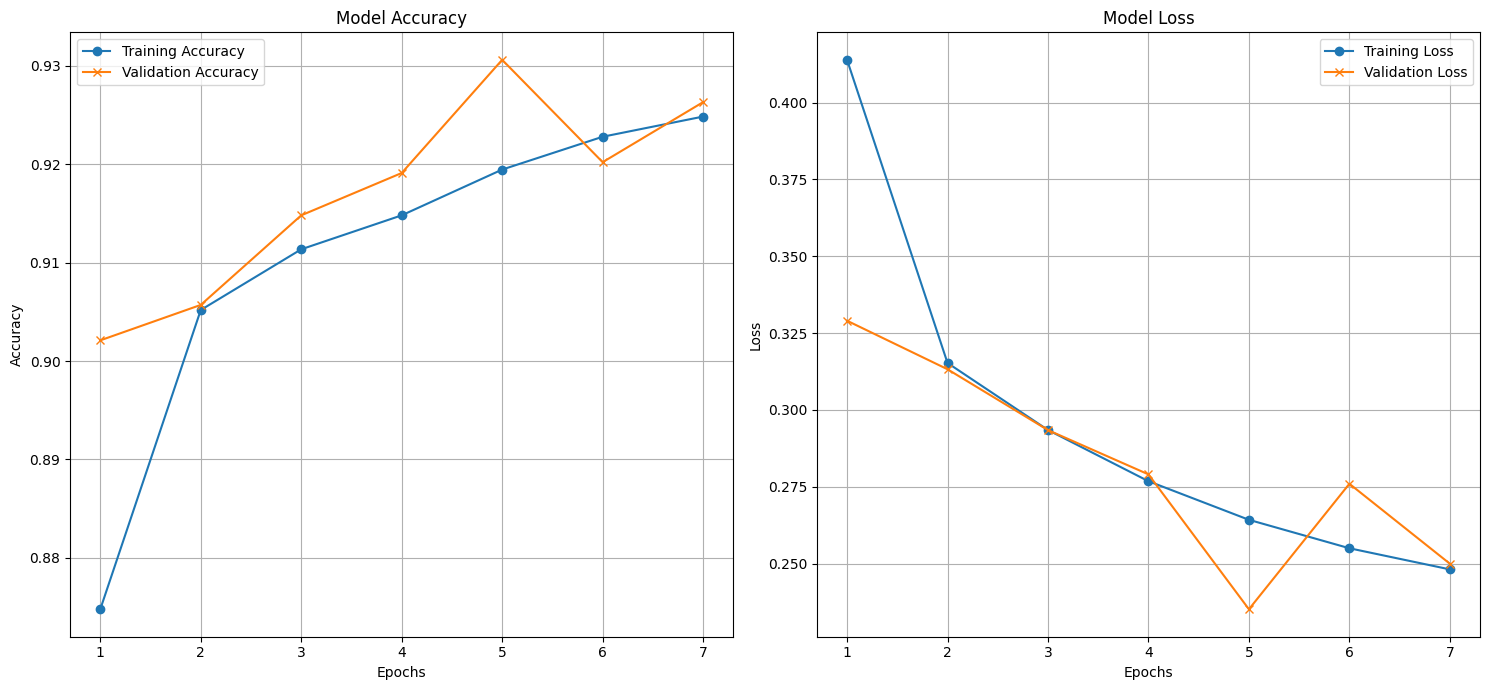

In [46]:
import matplotlib.pyplot as plt

# 1. Trích xuất dữ liệu từ history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(15, 7))
# --- Biểu đồ Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')
plt.grid(True)

# --- Biểu đồ Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)


plt.tight_layout()
plt.show()